# PETalytics — VAE Training on ESM-2 Embeddings (v3: resumable + tracked)


## 1. Setup

In [ ]:
!pip install -q optuna

import os
import json
import shutil
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

from google.colab import drive
drive.mount('/content/drive')

EMB_DIR = '/content/drive/MyDrive/petalytics/embeddings'
VAE_DIR = '/content/drive/MyDrive/petalytics/vae'
os.makedirs(VAE_DIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.7 MB/s eta 0:00:00
Device: cuda


ValueError: mount failed

## 2. Load the ESM-2 embeddings from ESM2 embedding generator notebook

In [ ]:
embeddings = np.load(os.path.join(EMB_DIR, 'esm2_150M_embeddings.npy'))
ids = np.load(os.path.join(EMB_DIR, 'esm2_150M_ids.npy'))
print('Embeddings shape:', embeddings.shape)
assert embeddings.shape[0] == ids.shape[0]
assert not np.isnan(embeddings).any(), 'NaNs in embeddings -- stop and investigate before training on this'

Embeddings shape: (50000, 640)


## 3. Train / validation / test split (70/15/15)
**Test set discipline:** `X_test` is not referenced again until the single
clearly-marked test evaluation cell near the end.

In [ ]:
idx = np.arange(len(embeddings))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)
print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

X_train_raw = embeddings[train_idx]
X_val_raw = embeddings[val_idx]
X_test_raw = embeddings[test_idx]

emb_mean = X_train_raw.mean(axis=0, keepdims=True)
emb_std = X_train_raw.std(axis=0, keepdims=True) + 1e-8

X_train = (X_train_raw - emb_mean) / emb_std
X_val = (X_val_raw - emb_mean) / emb_std
X_test = (X_test_raw - emb_mean) / emb_std

np.save(os.path.join(EMB_DIR, 'vae_emb_mean.npy'), emb_mean)
np.save(os.path.join(EMB_DIR, 'vae_emb_std.npy'), emb_std)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

Train: 35000, Val: 7500, Test: 7500


## 4. The VAE

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        encoder_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            encoder_layers += [nn.Linear(prev_dim, h), nn.ReLU()]
            prev_dim = h
        self.encoder_backbone = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        decoder_layers = []
        prev_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers += [nn.Linear(prev_dim, h), nn.ReLU()]
            prev_dim = h
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder_backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

## 5. Loss function

In [ ]:
BETA_TARGET = 1.0

def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

def get_beta(epoch, warmup_epochs):
    if epoch >= warmup_epochs:
        return BETA_TARGET
    return BETA_TARGET * (epoch / warmup_epochs)

## 6. Training function for search trials (fast, ephemeral, no checkpointing)
Search trials are short (15 epochs) and cheap to redo, so they don't need resumability -- only the
long final run does.

In [ ]:
def train_vae(hidden_dims, latent_dim, learning_rate, batch_size, kl_warmup_epochs,
               num_epochs, verbose=True):
    model = VAE(input_dim=X_train.shape[1], hidden_dims=hidden_dims, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_val_t), batch_size=batch_size, shuffle=False)

    history = {'train_recon': [], 'train_kl': [], 'val_recon': [], 'val_kl': []}

    for epoch in range(num_epochs):
        beta = get_beta(epoch, kl_warmup_epochs)
        model.train()
        train_recon_sum, train_kl_sum, n_train = 0.0, 0.0, 0
        for (batch,) in train_loader:
            batch = batch.to(device)
            recon, mu, logvar = model(batch)
            loss, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar, beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_recon_sum += recon_loss.item() * len(batch)
            train_kl_sum += kl_loss.item() * len(batch)
            n_train += len(batch)

        model.eval()
        val_recon_sum, val_kl_sum, n_val = 0.0, 0.0, 0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                recon, mu, logvar = model(batch)
                _, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar, beta)
                val_recon_sum += recon_loss.item() * len(batch)
                val_kl_sum += kl_loss.item() * len(batch)
                n_val += len(batch)

        history['train_recon'].append(train_recon_sum / n_train)
        history['train_kl'].append(train_kl_sum / n_train)
        history['val_recon'].append(val_recon_sum / n_val)
        history['val_kl'].append(val_kl_sum / n_val)

        if verbose and (epoch % 5 == 0 or epoch == num_epochs - 1):
            print(f'Epoch {epoch:3d} | beta={beta:.3f} | '
                  f'train recon={history["train_recon"][-1]:.4f} | '
                  f'val recon={history["val_recon"][-1]:.4f} kl={history["val_kl"][-1]:.4f}')

    return model, history

## 7. Optuna hyperparameter search — resumable, backed up to Drive after every trial
The live database lives on local Colab disk (`LOCAL_STUDY_DB`) for speed/reliability, and gets copied
to Drive (`DRIVE_STUDY_DB`) after every single trial via a callback -- so a disconnect only costs you
at most one in-progress trial, not the whole search. On restart, if a Drive backup exists and no
local copy does, it's restored first. **Re-running this cell after a disconnect just works — it
computes how many trials are already done and only runs the remainder.**

Each trial's full per-epoch history is stored as a user attribute, not just its final score, so you
can plot individual trial curves later without re-running anything.

In [ ]:
N_TRIALS = 20
SEARCH_EPOCHS = 15

LOCAL_STUDY_DB = '/content/optuna_study.db'
DRIVE_STUDY_DB = os.path.join(VAE_DIR, 'optuna_study.db')

if os.path.exists(DRIVE_STUDY_DB) and not os.path.exists(LOCAL_STUDY_DB):
    shutil.copy(DRIVE_STUDY_DB, LOCAL_STUDY_DB)
    print('Restored previous study database from Drive.')

def objective(trial):
    hidden_dim_1 = trial.suggest_categorical('hidden_dim_1', [128, 256, 512])
    hidden_dim_2 = trial.suggest_categorical('hidden_dim_2', [32, 64, 128])
    latent_dim = trial.suggest_int('latent_dim', 8, 64, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    kl_warmup_epochs = trial.suggest_int('kl_warmup_epochs', 2, 8)

    _, history = train_vae(
        hidden_dims=[hidden_dim_1, hidden_dim_2],
        latent_dim=latent_dim,
        learning_rate=learning_rate,
        batch_size=batch_size,
        kl_warmup_epochs=kl_warmup_epochs,
        num_epochs=SEARCH_EPOCHS,
        verbose=False,
    )
    trial.set_user_attr('history', history)  # full per-epoch curve, for later plotting
    return history['val_recon'][-1]

def backup_db_callback(study, trial):
    shutil.copy(LOCAL_STUDY_DB, DRIVE_STUDY_DB)

study = optuna.create_study(
    study_name='petalytics_vae_search',
    storage=f'sqlite:///{LOCAL_STUDY_DB}',
    load_if_exists=True,
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS - n_complete)
print(f'{n_complete} trials already completed. Running {remaining} more.')

if remaining > 0:
    study.optimize(objective, n_trials=remaining, callbacks=[backup_db_callback])
else:
    print('Target trial count already reached -- skipping search, using existing results.')

shutil.copy(LOCAL_STUDY_DB, DRIVE_STUDY_DB)  # final backup, redundant with per-trial but harmless
study.trials_dataframe().to_csv(os.path.join(VAE_DIR, 'optuna_trials.csv'), index=False)

print('Best validation reconstruction loss:', study.best_value)
print('Best hyperparameters:', study.best_params)

[I 2026-07-16 08:33:13,760] A new study created in RDB with name: petalytics_vae_search


0 trials already completed. Running 20 more.


[I 2026-07-16 08:33:42,182] Trial 0 finished with value: 152.88720545247395 and parameters: {'hidden_dim_1': 128, 'hidden_dim_2': 128, 'latent_dim': 25, 'learning_rate': 0.00012913957105420524, 'batch_size': 64, 'kl_warmup_epochs': 5}. Best is trial 0 with value: 152.88720545247395.
[I 2026-07-16 08:33:52,519] Trial 1 finished with value: 186.89392989095052 and parameters: {'hidden_dim_1': 512, 'hidden_dim_2': 32, 'latent_dim': 10, 'learning_rate': 0.009638065759473326, 'batch_size': 256, 'kl_warmup_epochs': 3}. Best is trial 0 with value: 152.88720545247395.
[I 2026-07-16 08:34:09,173] Trial 2 finished with value: 127.34276770833333 and parameters: {'hidden_dim_1': 128, 'hidden_dim_2': 64, 'latent_dim': 23, 'learning_rate': 0.004145233345258286, 'batch_size': 128, 'kl_warmup_epochs': 2}. Best is trial 2 with value: 127.34276770833333.
[I 2026-07-16 08:34:25,571] Trial 3 finished with value: 171.00653791503908 and parameters: {'hidden_dim_1': 512, 'hidden_dim_2': 128, 'latent_dim': 9, 

Best validation reconstruction loss: 94.9143945678711
Best hyperparameters: {'hidden_dim_1': 256, 'hidden_dim_2': 128, 'latent_dim': 36, 'learning_rate': 0.001354137386481273, 'batch_size': 128, 'kl_warmup_epochs': 7}


## 8. Search diagnostics

/tmp/ipykernel_12000/1740577960.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


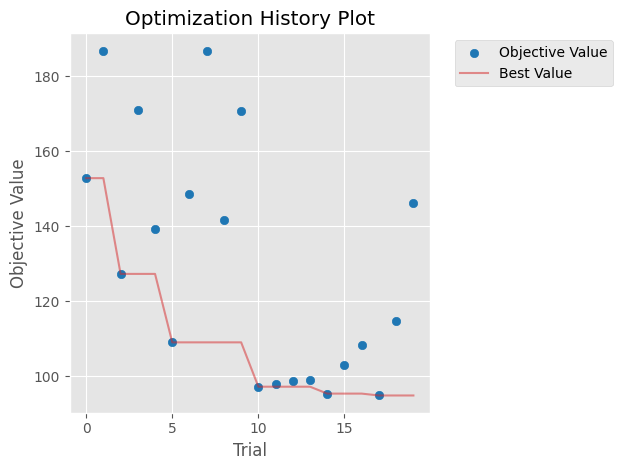

/tmp/ipykernel_12000/1740577960.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


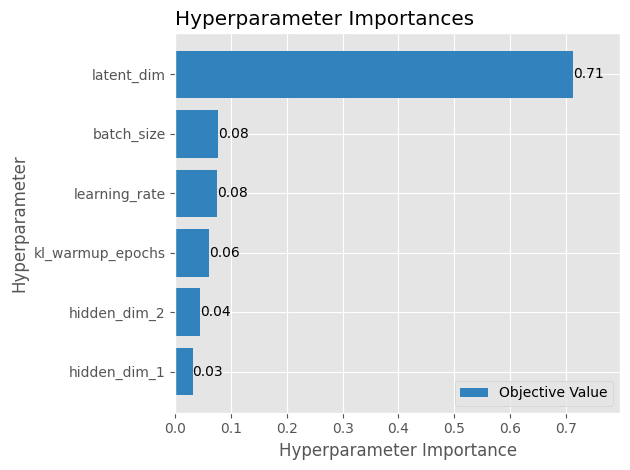

In [ ]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.tight_layout()
plt.savefig('/content/optuna_history.png', dpi=150)
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.savefig('/content/optuna_importances.png', dpi=150)
plt.show()

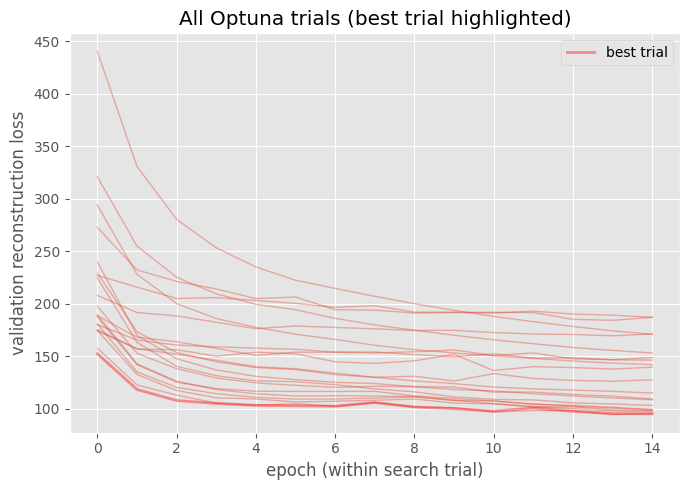

In [ ]:
# Bonus: overlay every trial's validation reconstruction curve, using the per-epoch histories
# stashed via set_user_attr above -- shows the search process itself, not just final scores.
plt.figure(figsize=(7, 5))
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE and 'history' in t.user_attrs:
        plt.plot(t.user_attrs['history']['val_recon'], alpha=0.4,
                 color='C0' if t.number != study.best_trial.number else 'red',
                 linewidth=2 if t.number == study.best_trial.number else 1,
                 label='best trial' if t.number == study.best_trial.number else None)
plt.xlabel('epoch (within search trial)')
plt.ylabel('validation reconstruction loss')
plt.title('All Optuna trials (best trial highlighted)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/optuna_all_trial_curves.png', dpi=150)
plt.show()

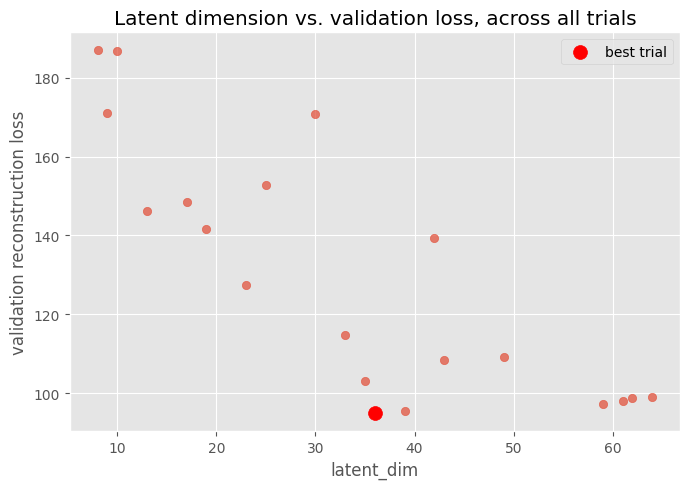

Best latent_dim found: 36 out of range [8, 64].


In [ ]:
trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE']

plt.figure(figsize=(7, 5))
plt.scatter(completed['params_latent_dim'], completed['value'], alpha=0.7)
best_row = completed.loc[completed['value'].idxmin()]
plt.scatter([best_row['params_latent_dim']], [best_row['value']], color='red', s=100,
            zorder=5, label='best trial')
plt.xlabel('latent_dim')
plt.ylabel('validation reconstruction loss')
plt.title('Latent dimension vs. validation loss, across all trials')
plt.legend()
plt.tight_layout()
plt.savefig('/content/latent_dim_vs_loss.png', dpi=150)
plt.show()

print('Best latent_dim found:', int(best_row['params_latent_dim']), 'out of range [8, 64].')
if best_row['params_latent_dim'] >= 56:
    print('This is near the top of the search range -- worth re-running with a wider range',
          '(e.g. up to 128) to check whether performance keeps improving beyond 64.')

## 9. Final training run — self-contained, resumable checkpoints
**Re-running this cell after a disconnect just works.** It checks for an existing checkpoint, and if
found, resumes from the saved epoch with the saved optimizer state -- no flags to set. The checkpoint
stores the hyperparameters alongside the weights, so it's self-describing: loading it elsewhere never
depends on a separate 'current best hyperparameters' file that might have since changed.

In [ ]:
FINAL_EPOCHS = 200
CHECKPOINT_EVERY = 5
PATIENCE = 20
CHECKPOINT_PATH = os.path.join(VAE_DIR, 'vae_final_checkpoint.pt')
BEST_CHECKPOINT_PATH = os.path.join(VAE_DIR, 'vae_best_val.pt')

best = study.best_params
hidden_dims = [best['hidden_dim_1'], best['hidden_dim_2']]

def train_vae_resumable(hidden_dims, latent_dim, learning_rate, batch_size, kl_warmup_epochs,
                          num_epochs, checkpoint_path, best_checkpoint_path,
                          checkpoint_every=5, patience=10):
    model = VAE(input_dim=X_train.shape[1], hidden_dims=hidden_dims, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    start_epoch = 0
    history = {'train_recon': [], 'train_kl': [], 'val_recon': [], 'val_kl': []}
    best_val_recon = float('inf')
    epochs_without_improvement = 0

    hp = {'hidden_dims': hidden_dims, 'latent_dim': latent_dim, 'learning_rate': learning_rate,
          'batch_size': batch_size, 'kl_warmup_epochs': kl_warmup_epochs, 'num_epochs': num_epochs}

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        history = ckpt['history']
        best_val_recon = ckpt.get('best_val_recon', float('inf'))
        epochs_without_improvement = ckpt.get('epochs_without_improvement', 0)
        print(f'Resuming from epoch {start_epoch} of {num_epochs}. '
              f'Best val recon so far: {best_val_recon:.4f} '
              f'({epochs_without_improvement}/{patience} epochs since improvement).')
        if start_epoch >= num_epochs:
            print('Checkpoint already reached target epoch count -- nothing more to train.')
            return model, history, best_val_recon
    else:
        print('No checkpoint found -- starting fresh.')

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_val_t), batch_size=batch_size, shuffle=False)

    for epoch in range(start_epoch, num_epochs):
        beta = get_beta(epoch, kl_warmup_epochs)
        model.train()
        train_recon_sum, train_kl_sum, n_train = 0.0, 0.0, 0
        for (batch,) in train_loader:
            batch = batch.to(device)
            recon, mu, logvar = model(batch)
            loss, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar, beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_recon_sum += recon_loss.item() * len(batch)
            train_kl_sum += kl_loss.item() * len(batch)
            n_train += len(batch)

        model.eval()
        val_recon_sum, val_kl_sum, n_val = 0.0, 0.0, 0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                recon, mu, logvar = model(batch)
                _, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar, beta)
                val_recon_sum += recon_loss.item() * len(batch)
                val_kl_sum += kl_loss.item() * len(batch)
                n_val += len(batch)

        history['train_recon'].append(train_recon_sum / n_train)
        history['train_kl'].append(train_kl_sum / n_train)
        current_val_recon = val_recon_sum / n_val
        history['val_recon'].append(current_val_recon)
        history['val_kl'].append(val_kl_sum / n_val)

        if current_val_recon < best_val_recon:
            best_val_recon = current_val_recon
            epochs_without_improvement = 0
            torch.save({'model_state_dict': model.state_dict(), 'hyperparams': hp,
                        'epoch': epoch, 'val_recon': best_val_recon}, best_checkpoint_path)
            print(f'Epoch {epoch:3d} | val recon={current_val_recon:.4f} | *** new best, saved ***')
        else:
            epochs_without_improvement += 1
            if epoch % checkpoint_every == 0 or epoch == num_epochs - 1:
                print(f'Epoch {epoch:3d} | val recon={current_val_recon:.4f} | '
                      f'{epochs_without_improvement}/{patience} epochs since improvement')

        if epoch % checkpoint_every == 0 or epoch == num_epochs - 1:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch, 'history': history, 'hyperparams': hp,
                'best_val_recon': best_val_recon,
                'epochs_without_improvement': epochs_without_improvement,
            }, checkpoint_path)

        if epochs_without_improvement >= patience:
            print(f'Early stopping at epoch {epoch}: no improvement for {patience} epochs. '
                  f'Best model (epoch {epoch - epochs_without_improvement}) is in {best_checkpoint_path}.')
            break

    return model, history, best_val_recon

model, history, best_val_recon = train_vae_resumable(
    hidden_dims=hidden_dims,
    latent_dim=best['latent_dim'],
    learning_rate=best['learning_rate'],
    batch_size=best['batch_size'],
    kl_warmup_epochs=best['kl_warmup_epochs'],
    num_epochs=FINAL_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    best_checkpoint_path=BEST_CHECKPOINT_PATH,
    checkpoint_every=CHECKPOINT_EVERY,
    patience=PATIENCE,
)

with open(os.path.join(VAE_DIR, 'final_training_history.json'), 'w') as f:
    json.dump(history, f)
print('Best validation reconstruction loss achieved:', best_val_recon)
print('Saved checkpoints and training history to', VAE_DIR)

NameError: name 'study' is not defined

## 10. Training curves (final run)

In [ ]:
best_epoch = int(np.argmin(history['val_recon']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_recon'], label='train')
axes[0].plot(history['val_recon'], label='val')
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
axes[0].set_title('Reconstruction loss (MSE)')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history['train_kl'], label='train')
axes[1].plot(history['val_kl'], label='val')
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('KL divergence')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/vae_training_curves.png', dpi=150)
plt.show()

if best_epoch < len(history['val_recon']) - 1:
    print(f'Note: validation loss kept being tracked {len(history["val_recon"]) - 1 - best_epoch} '
          f'epochs past its best point (epoch {best_epoch}) before stopping/finishing -- exactly the',
          'overfitting pattern you saw with large_net in Lab 2. vae_best_val.pt holds the epoch',
          f'{best_epoch} model, not whatever the training loop ended on.')

NameError: name 'history' is not defined

## 11. Test evaluation — the ONLY cell that touches X_test
Run this exactly once, after everything above is finished.

In [ ]:
best_ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device)
best_hp = best_ckpt['hyperparams']
eval_model = VAE(input_dim=X_train.shape[1], hidden_dims=best_hp['hidden_dims'],
                 latent_dim=best_hp['latent_dim']).to(device)
eval_model.load_state_dict(best_ckpt['model_state_dict'])
eval_model.eval()
print(f'Loaded best-validation checkpoint from epoch {best_ckpt["epoch"]}',
      f'(val recon={best_ckpt["val_recon"]:.4f}) for test evaluation.')

with torch.no_grad():
    recon_test, mu_test, logvar_test = eval_model(X_test_t.to(device))
recon_test_np = recon_test.cpu().numpy()

# Same formula used for val_recon during training (sum over dims, mean over batch) -- directly
# comparable to the val recon printed above, unlike R2 which is a different metric/scale.
test_recon_loss = nn.functional.mse_loss(
    recon_test, X_test_t.to(device), reduction='sum').item() / X_test_t.size(0)
print(f'TEST reconstruction loss: {test_recon_loss:.4f}  (val recon was {best_ckpt["val_recon"]:.4f})')

ss_res = ((X_test - recon_test_np) ** 2).sum(axis=0)
ss_tot = ((X_test - X_test.mean(axis=0)) ** 2).sum(axis=0)
r2_per_dim = 1 - ss_res / ss_tot
print('TEST SET reconstruction R2 -- mean:', r2_per_dim.mean())
print('TEST SET reconstruction R2 -- min / max:', r2_per_dim.min(), '/', r2_per_dim.max())

Loaded best-validation checkpoint from epoch 93 (val recon=80.3210) for test evaluation.
TEST reconstruction loss: 80.4829  (val recon was 80.3210)
TEST SET reconstruction R2 -- mean: 0.8737976
TEST SET reconstruction R2 -- min / max: 0.76740515 / 0.95374495


In [ ]:
from sklearn.decomposition import PCA

if 'best_hp' not in dir() or 'r2_per_dim' not in dir():
    print('section 11 has not been run yet in this session -- reconstructing what this cell needs.')
    best_ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device)
    best_hp = best_ckpt['hyperparams']
    eval_model = VAE(input_dim=X_train.shape[1], hidden_dims=best_hp['hidden_dims'],
                     latent_dim=best_hp['latent_dim']).to(device)
    eval_model.load_state_dict(best_ckpt['model_state_dict'])
    eval_model.eval()
    with torch.no_grad():
        recon_test, _, _ = eval_model(X_test_t.to(device))
    recon_test_np = recon_test.cpu().numpy()
    ss_res = ((X_test - recon_test_np) ** 2).sum(axis=0)
    ss_tot = ((X_test - X_test.mean(axis=0)) ** 2).sum(axis=0)
    r2_per_dim = 1 - ss_res / ss_tot

pca_baseline = PCA(n_components=best_hp['latent_dim'], random_state=42)
pca_baseline.fit(X_train)

X_test_pca_recon = pca_baseline.inverse_transform(pca_baseline.transform(X_test))

ss_res_pca = ((X_test - X_test_pca_recon) ** 2).sum(axis=0)
ss_tot_pca = ((X_test - X_test.mean(axis=0)) ** 2).sum(axis=0)
r2_per_dim_pca = 1 - ss_res_pca / ss_tot_pca

print(f'VAE test R2 (mean):  {r2_per_dim.mean():.4f}')
print(f'PCA test R2 (mean):  {r2_per_dim_pca.mean():.4f}')
print(f'Difference: {r2_per_dim.mean() - r2_per_dim_pca.mean():+.4f}')
print()
print('PCA explained variance ratio, cumulative at', best_hp['latent_dim'], 'components:',
      pca_baseline.explained_variance_ratio_.sum())

VAE test R2 (mean):  0.8738
PCA test R2 (mean):  0.8134
Difference: +0.0604

PCA explained variance ratio, cumulative at 36 components: 0.81279224


## 12. Qualitative check: PCA of the latent space (test set)

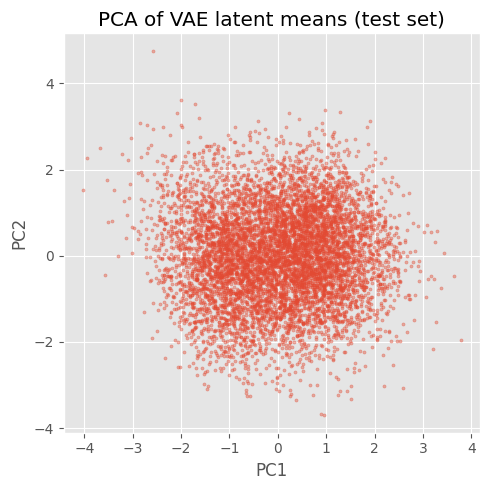

In [ ]:
mu_test_np = mu_test.cpu().numpy()
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(mu_test_np)

plt.figure(figsize=(5, 5))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], s=5, alpha=0.4)
plt.title('PCA of VAE latent means (test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('/content/vae_latent_pca.png', dpi=150)
plt.show()

## 12.B More Graphs

In [ ]:
!pip install -q umap-learn

import time
import pandas as pd
from datasets import load_dataset
import umap

with open(os.path.join(EMB_DIR, 'dataset_revision.txt')) as f:
    DATASET_REVISION = f.read().strip()

t0 = time.time()
ds_full = load_dataset('petadex/catalytic-orfs-90pid', split='train', revision=DATASET_REVISION)
id_lookup_df = ds_full.select_columns(['ORF ID', 'Genbank Acc']).to_pandas()
print(f'Loaded lookup columns for {len(id_lookup_df)} rows in {time.time() - t0:.1f}s.')

id_lookup_df['provenance'] = np.where(id_lookup_df['Genbank Acc'].notna(), 'reference', 'predicted_orf')
id_lookup_df = id_lookup_df.set_index('ORF ID')

test_ids = ids[test_idx]
test_provenance = id_lookup_df.reindex(test_ids)['provenance'].fillna('unknown').values
print('Provenance breakdown in test set:', pd.Series(test_provenance).value_counts().to_dict())

README.md:   0%|          | 0.00/773 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

data/train-00003-of-00013.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/54.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17809500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/181730 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/181730 [00:00<?, ? examples/s]

Loaded lookup columns for 17809500 rows in 60.0s.
Provenance breakdown in test set: {'predicted_orf': 6236, 'reference': 1264}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


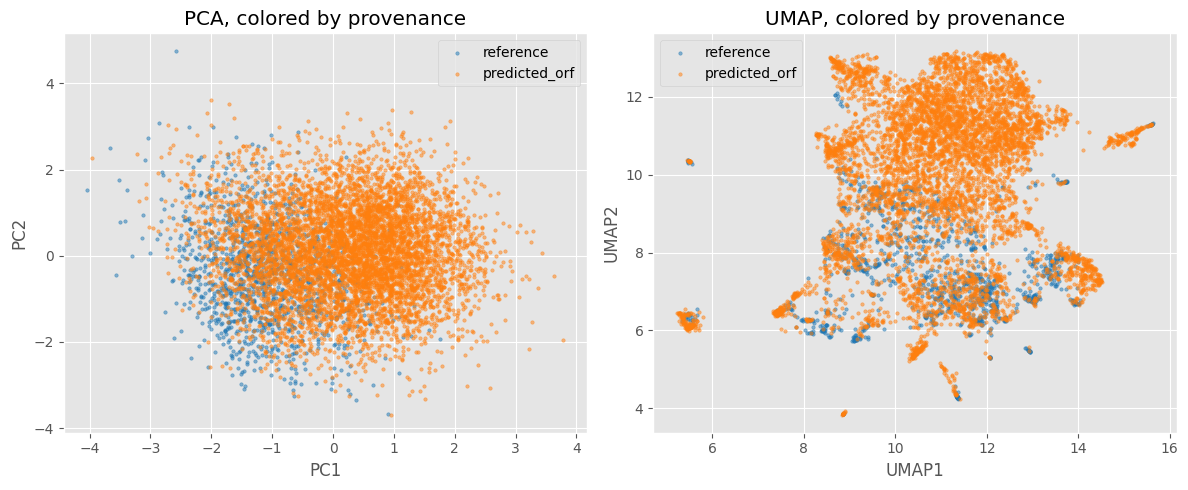

In [ ]:
colors = {'reference': 'tab:blue', 'predicted_orf': 'tab:orange', 'unknown': 'lightgray'}
point_colors = [colors[p] for p in test_provenance]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label in ['reference', 'predicted_orf']:
    mask = test_provenance == label
    axes[0].scatter(latent_2d[mask, 0], latent_2d[mask, 1], s=6, alpha=0.5,
                     color=colors[label], label=label)
axes[0].set_title('PCA, colored by provenance')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
latent_umap = reducer.fit_transform(mu_test_np)
for label in ['reference', 'predicted_orf']:
    mask = test_provenance == label
    axes[1].scatter(latent_umap[mask, 0], latent_umap[mask, 1], s=6, alpha=0.5,
                     color=colors[label], label=label)
axes[1].set_title('UMAP, colored by provenance')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/vae_latent_pca_umap_provenance.png', dpi=150)
plt.show()

## 12.c even more graphs

In [ ]:
if 'ds_full' not in dir():
    from datasets import load_dataset
    with open(os.path.join(EMB_DIR, 'dataset_revision.txt')) as f:
        DATASET_REVISION = f.read().strip()
    ds_full = load_dataset('petadex/catalytic-orfs-90pid', split='train', revision=DATASET_REVISION)

length_lookup_df = ds_full.select_columns(['ORF ID', 'Sequence']).to_pandas()
length_lookup_df['seq_length'] = length_lookup_df['Sequence'].str.len()
length_lookup_df = length_lookup_df.set_index('ORF ID')

test_lengths = length_lookup_df.reindex(test_ids)['seq_length'].values
print('Test set sequence length stats:')
print(pd.Series(test_lengths).describe())

Test set sequence length stats:
count    7500.000000
mean      204.005067
std       160.242613
min        36.000000
25%        78.000000
50%       151.000000
75%       291.000000
max      1004.000000
dtype: float64


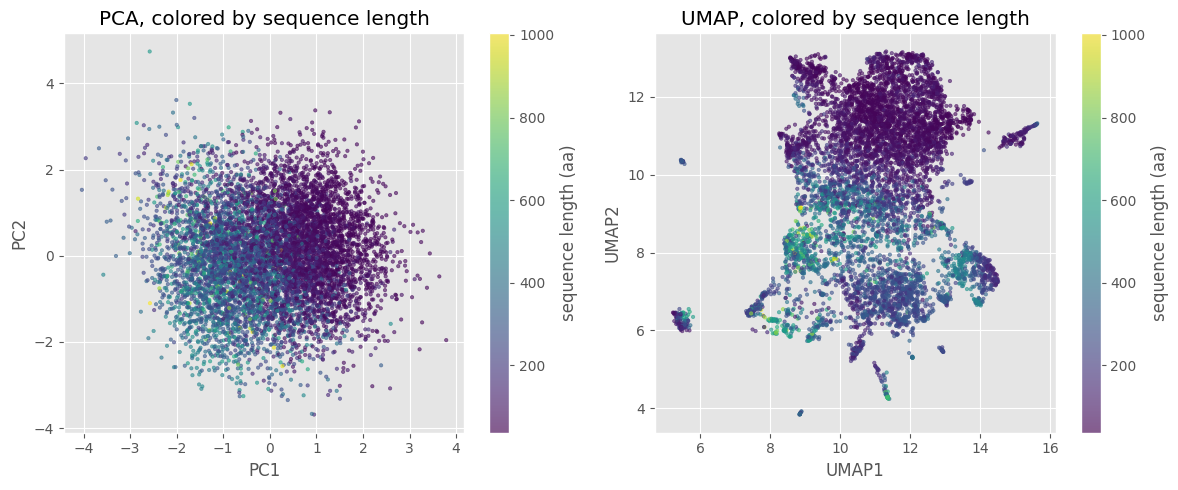

Correlation of PC1 with sequence length: r=-0.587 (p=0.00e+00)
Correlation of PC2 with sequence length: r=-0.246 (p=1.83e-103)

Sequence length by provenance (does predicted_orf skew shorter, as hypothesized?):
                count        mean         std    min    25%    50%    75%  \
provenance                                                                  
predicted_orf  6236.0  163.889833  130.240092   36.0   72.0  109.5  226.0   
reference      1264.0  401.915348  146.891340  146.0  288.0  366.0  483.0   

                  max  
provenance             
predicted_orf  1004.0  
reference       997.0  


In [ ]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(latent_2d[:, 0], latent_2d[:, 1], s=6, alpha=0.6, c=test_lengths, cmap='viridis')
axes[0].set_title('PCA, colored by sequence length')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc0, ax=axes[0], label='sequence length (aa)')

sc1 = axes[1].scatter(latent_umap[:, 0], latent_umap[:, 1], s=6, alpha=0.6, c=test_lengths, cmap='viridis')
axes[1].set_title('UMAP, colored by sequence length')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')
plt.colorbar(sc1, ax=axes[1], label='sequence length (aa)')

plt.tight_layout()
plt.savefig('/content/vae_latent_pca_umap_length.png', dpi=150)
plt.show()

r_pc1, p_pc1 = pearsonr(test_lengths, latent_2d[:, 0])
r_pc2, p_pc2 = pearsonr(test_lengths, latent_2d[:, 1])
print(f'Correlation of PC1 with sequence length: r={r_pc1:.3f} (p={p_pc1:.2e})')
print(f'Correlation of PC2 with sequence length: r={r_pc2:.3f} (p={p_pc2:.2e})')
print()
print('Sequence length by provenance (does predicted_orf skew shorter, as hypothesized?):')
print(pd.DataFrame({'length': test_lengths, 'provenance': test_provenance})
      .groupby('provenance')['length'].describe())


## 13. Extract and save latent vectors for all sequences

In [ ]:
eval_model.eval()
all_X = (embeddings - emb_mean) / emb_std
all_X_t = torch.tensor(all_X, dtype=torch.float32).to(device)

with torch.no_grad():
    all_mu, _ = eval_model.encode(all_X_t)
all_mu = all_mu.cpu().numpy()

np.save(os.path.join(VAE_DIR, 'latent_vectors.npy'), all_mu)
np.save(os.path.join(VAE_DIR, 'latent_vector_ids.npy'), ids)
print('Saved latent vectors:', all_mu.shape, 'for', len(ids), 'sequences.')

Saved latent vectors: (50000, 36) for 50000 sequences.
